In [1]:
import fastf1
import pandas as pd
import matplotlib.pyplot as plt

# Connect back to the local tracking cache directory
fastf1.Cache.enable_cache('../cache')

# Ingest cached arrays
session = fastf1.get_session(2023, 'Monaco', 'R')
session.load(telemetry=True, laps=True)

core           INFO 	Loading data for Monaco Grand Prix - Race [v3.8.3]
req            INFO 	Using cached data for session_info
req            INFO 	Using cached data for driver_info
req            INFO 	Using cached data for session_status_data
req            INFO 	Using cached data for lap_count
req            INFO 	Using cached data for track_status_data
req            INFO 	Using cached data for _extended_timing_data
req            INFO 	Using cached data for timing_app_data
core           INFO 	Processing timing data...
req            INFO 	Using cached data for car_data
req            INFO 	Using cached data for position_data
req            INFO 	Using cached data for weather_data
req            INFO 	Using cached data for race_control_messages
core           INFO 	Finished loading data for 20 drivers: ['1', '14', '31', '44', '63', '16', '10', '55', '4', '81', '77', '21', '24', '23', '22', '11', '27', '2', '20', '18']


In [2]:
# UPDATED: Singular API function alignment 
try:
    ver_lap = session.laps.pick_driver('VER').pick_fastest()
except AttributeError:
    ver_lap = session.laps.pick_drivers('VER').pick_fastest()

# Extract continuous multi-channel streaming tracking samples
telemetry = ver_lap.get_telemetry()

print("Telemetry Dataframe Core Schema Verification:")
print(telemetry[['Time', 'Speed', 'RPM', 'nGear', 'Throttle', 'Brake']].head(10))

D:\Projects\F1 Telemetry\f1-telemetry-ml\venv\Lib\site-packages\fastf1\core.py:3175: FutureWarning: pick_driver is deprecated and will be removed in a future release. Use pick_drivers instead.
  warnings.warn(("pick_driver is deprecated and will be removed"


Telemetry Dataframe Core Schema Verification:
                     Time       Speed           RPM  nGear    Throttle  Brake
2         0 days 00:00:00  263.750000  11091.000000      6  100.000000  False
3  0 days 00:00:00.040000  264.000000  10916.000000      6  100.000000  False
4  0 days 00:00:00.064000  264.300000  10900.820000      6   99.700000  False
5  0 days 00:00:00.264000  266.800000  10774.320000      6   97.200000  False
6  0 days 00:00:00.440000  269.000000  10663.000000      7   95.000000  False
7  0 days 00:00:00.624000  266.371429  10563.114286      7   32.571429  False
8  0 days 00:00:00.720000  265.000000  10511.000000      7    0.000000  False
9  0 days 00:00:00.824000  261.912500  10348.662500      7    0.000000  False
10 0 days 00:00:01.324000  247.068758   9568.194150      7    0.000000  False
11 0 days 00:00:01.360000  246.000000   9512.000000      7    0.000000   True


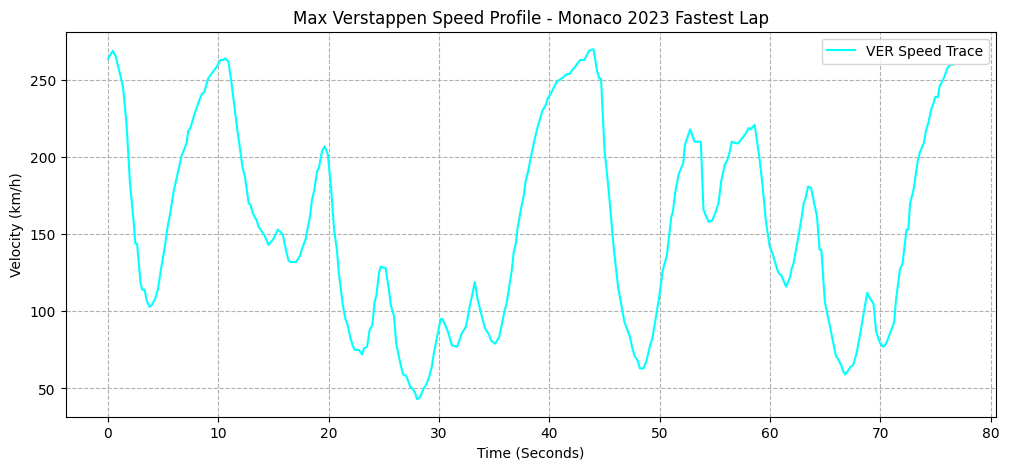

In [3]:
plt.figure(figsize=(12, 5))
plt.plot(telemetry['Time'].dt.total_seconds(), telemetry['Speed'], label='VER Speed Trace', color='cyan')
plt.title('Max Verstappen Speed Profile - Monaco 2023 Fastest Lap')
plt.xlabel('Time (Seconds)')
plt.ylabel('Velocity (km/h)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

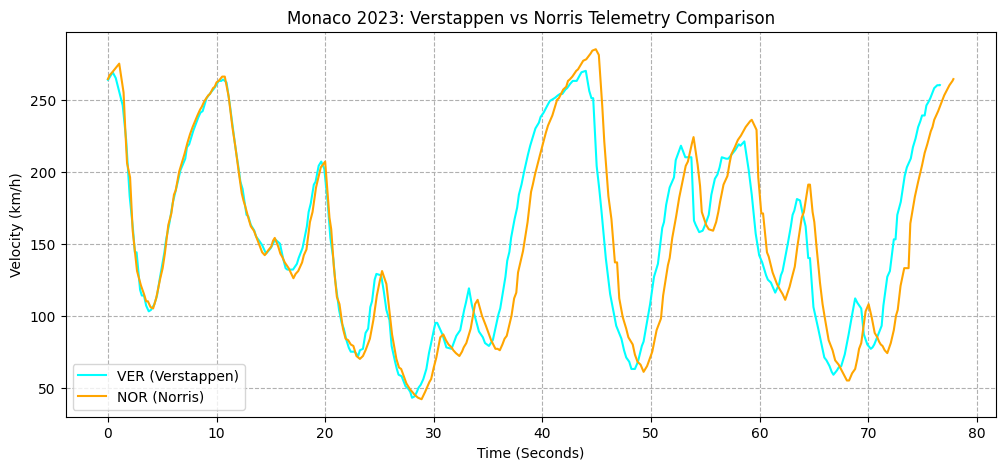

In [4]:
import matplotlib.pyplot as plt

# 1. Get Verstappen's fastest lap and telemetry
ver_lap = session.laps.pick_drivers('VER').pick_fastest()
ver_telemetry = ver_lap.get_telemetry()

# 2. Get Lando Norris's fastest lap and telemetry
nor_lap = session.laps.pick_drivers('NOR').pick_fastest()
nor_telemetry = nor_lap.get_telemetry()

# 3. Plot both lines together for comparison
plt.figure(figsize=(12, 5))
plt.plot(ver_telemetry['Time'].dt.total_seconds(), ver_telemetry['Speed'], label='VER (Verstappen)', color='cyan')
plt.plot(nor_telemetry['Time'].dt.total_seconds(), nor_telemetry['Speed'], label='NOR (Norris)', color='orange')

# 4. Customize chart visuals
plt.title('Monaco 2023: Verstappen vs Norris Telemetry Comparison')
plt.xlabel('Time (Seconds)')
plt.ylabel('Velocity (km/h)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

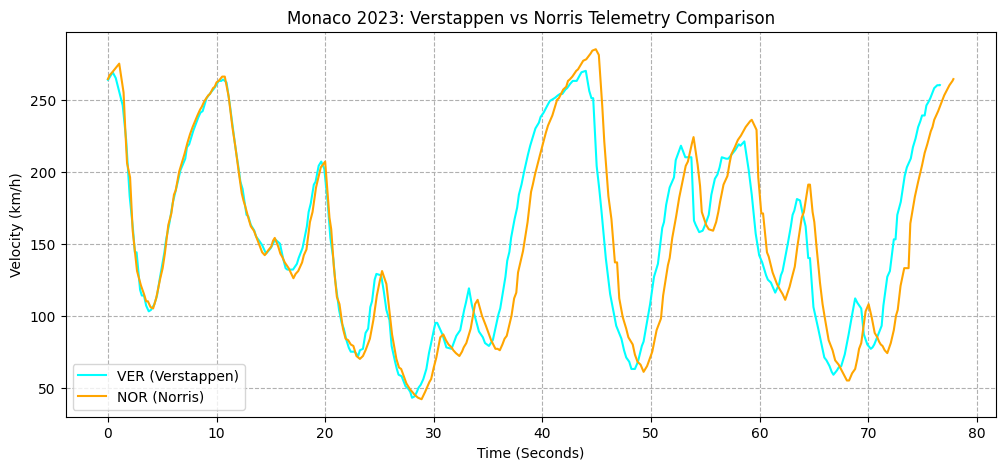

In [12]:
import matplotlib.pyplot as plt

# 1. Get Verstappen's fastest lap and telemetry
ver_lap = session.laps.pick_drivers('VER').pick_fastest()
ver_telemetry = ver_lap.get_telemetry()

# 2. Get Lando Norris's fastest lap and telemetry
nor_lap = session.laps.pick_drivers('NOR').pick_fastest()
nor_telemetry = nor_lap.get_telemetry()

# 3. Plot both lines together for comparison
plt.figure(figsize=(12, 5))
plt.plot(ver_telemetry['Time'].dt.total_seconds(), ver_telemetry['Speed'], label='VER (Verstappen)', color='cyan')
plt.plot(nor_telemetry['Time'].dt.total_seconds(), nor_telemetry['Speed'], label='NOR (Norris)', color='orange')

# 4. Customize chart visuals
plt.title('Monaco 2023: Verstappen vs Norris Telemetry Comparison')
plt.xlabel('Time (Seconds)')
plt.ylabel('Velocity (km/h)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()

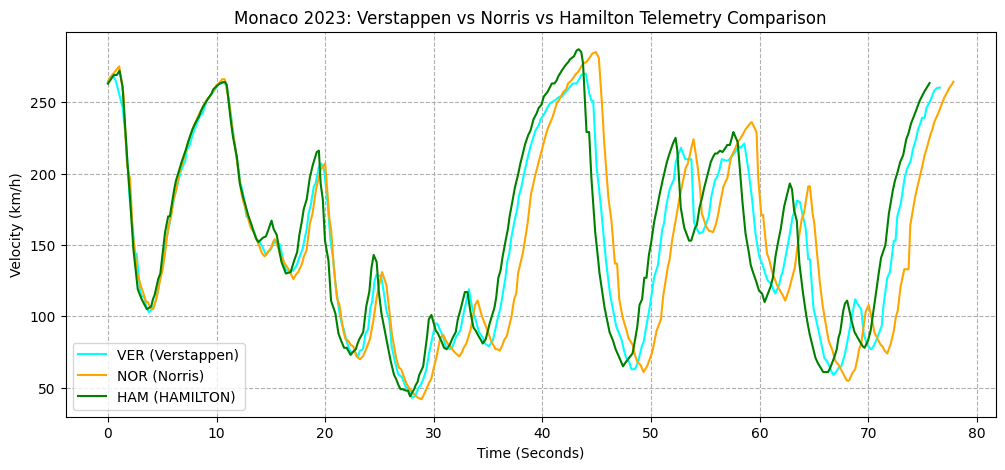

In [13]:
import matplotlib.pyplot as plt

# 1. Get Verstappen's fastest lap and telemetry
ver_lap = session.laps.pick_drivers('VER').pick_fastest()
ver_telemetry = ver_lap.get_telemetry()

# 2. Get Lando Norris's fastest lap and telemetry
nor_lap = session.laps.pick_drivers('NOR').pick_fastest()
nor_telemetry = nor_lap.get_telemetry()

#HAMILTON
ham_lap = session.laps.pick_drivers('HAM').pick_fastest()
ham_telemetry = ham_lap.get_telemetry()

# 3. Plot lines together for comparison
plt.figure(figsize=(12, 5))
plt.plot(ver_telemetry['Time'].dt.total_seconds(), ver_telemetry['Speed'], label='VER (Verstappen)', color='cyan')
plt.plot(nor_telemetry['Time'].dt.total_seconds(), nor_telemetry['Speed'], label='NOR (Norris)', color='orange')
plt.plot(ham_telemetry['Time'].dt.total_seconds(), ham_telemetry['Speed'], label='HAM (HAMILTON)', color='green')

# 4. Customize chart visuals
plt.title('Monaco 2023: Verstappen vs Norris vs Hamilton Telemetry Comparison')
plt.xlabel('Time (Seconds)')
plt.ylabel('Velocity (km/h)')
plt.grid(True, linestyle='--')
plt.legend()
plt.show()